# Human Activity Recognition with HMMs

Using accelerometer + gyroscope data collected from Sensor Logger (iPhone 13)
to classify 4 activities: standing, walking, jumping, still.
Sampling rate: 100 Hz.

## 1. Imports

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.fft import fft, fftfreq
from scipy.signal import welch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, recall_score
)
from hmmlearn import hmm
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

ACTIVITIES = ['standing', 'walking', 'jumping', 'still']
ACTIVITY_MAP = {name: idx for idx, name in enumerate(ACTIVITIES)}
N_STATES = len(ACTIVITIES)

print(f"Activities: {ACTIVITIES}")
print(f"Number of hidden states: {N_STATES}")

Activities: ['standing', 'walking', 'jumping', 'still']
Number of hidden states: 4


## 2. Data Loading

Sensor Logger exports each recording as a folder with separate CSVs per sensor.
I take Accelerometer.csv and Gyroscope.csv from each, merge them, and label them.

In [4]:
DATA_DIR = "Data"

def load_recording(folder_path):
    accel_path = os.path.join(folder_path, "Accelerometer.csv")
    gyro_path = os.path.join(folder_path, "Gyroscope.csv")

    if not os.path.exists(accel_path) or not os.path.exists(gyro_path):
        return None

    accel = pd.read_csv(accel_path)
    gyro = pd.read_csv(gyro_path)

    accel = accel.rename(columns={'x': 'accel_x', 'y': 'accel_y', 'z': 'accel_z'})
    gyro = gyro.rename(columns={'x': 'gyro_x', 'y': 'gyro_y', 'z': 'gyro_z'})

    accel = accel.sort_values('time').reset_index(drop=True)
    gyro = gyro.sort_values('time').reset_index(drop=True)

    # merge on nearest timestamp since the two sensors aren't perfectly synced
    merged = pd.merge_asof(
        accel[['time', 'seconds_elapsed', 'accel_x', 'accel_y', 'accel_z']],
        gyro[['time', 'gyro_x', 'gyro_y', 'gyro_z']],
        on='time',
        direction='nearest'
    )
    return merged

def load_all_data(data_dir):
    all_data = []
    for activity in ACTIVITIES:
        activity_dir = os.path.join(data_dir, activity.capitalize())
        if not os.path.exists(activity_dir):
            print(f"  Warning: {activity_dir} not found")
            continue

        folders = [
            d for d in sorted(glob.glob(os.path.join(activity_dir, f"{activity}*")))
            if os.path.isdir(d)
        ]

        print(f"  {activity.capitalize()}: {len(folders)} recordings")

        for folder in folders:
            data = load_recording(folder)
            if data is not None:
                data['activity'] = activity
                data['activity_id'] = ACTIVITY_MAP[activity]
                data['recording'] = os.path.basename(folder)
                all_data.append(data)
    return all_data

print("Loading sensor data...")
recordings = load_all_data(DATA_DIR)
print(f"\nLoaded {len(recordings)} recordings total")

for activity in ACTIVITIES:
    count = sum(1 for r in recordings if r['activity'].iloc[0] == activity)
    total_pts = sum(len(r) for r in recordings if r['activity'].iloc[0] == activity)
    print(f"  {activity.capitalize():10s}: {count:2d} recordings, {total_pts:5d} data points")

Loading sensor data...
  Standing: 10 recordings
  Walking: 12 recordings
  Jumping: 12 recordings
  Still: 12 recordings

Loaded 46 recordings total
  Standing  : 10 recordings,  8210 data points
  Walking   : 12 recordings, 10817 data points
  Jumping   : 12 recordings, 12586 data points
  Still     : 12 recordings,  9951 data points


## 3. Exploratory Data Analysis

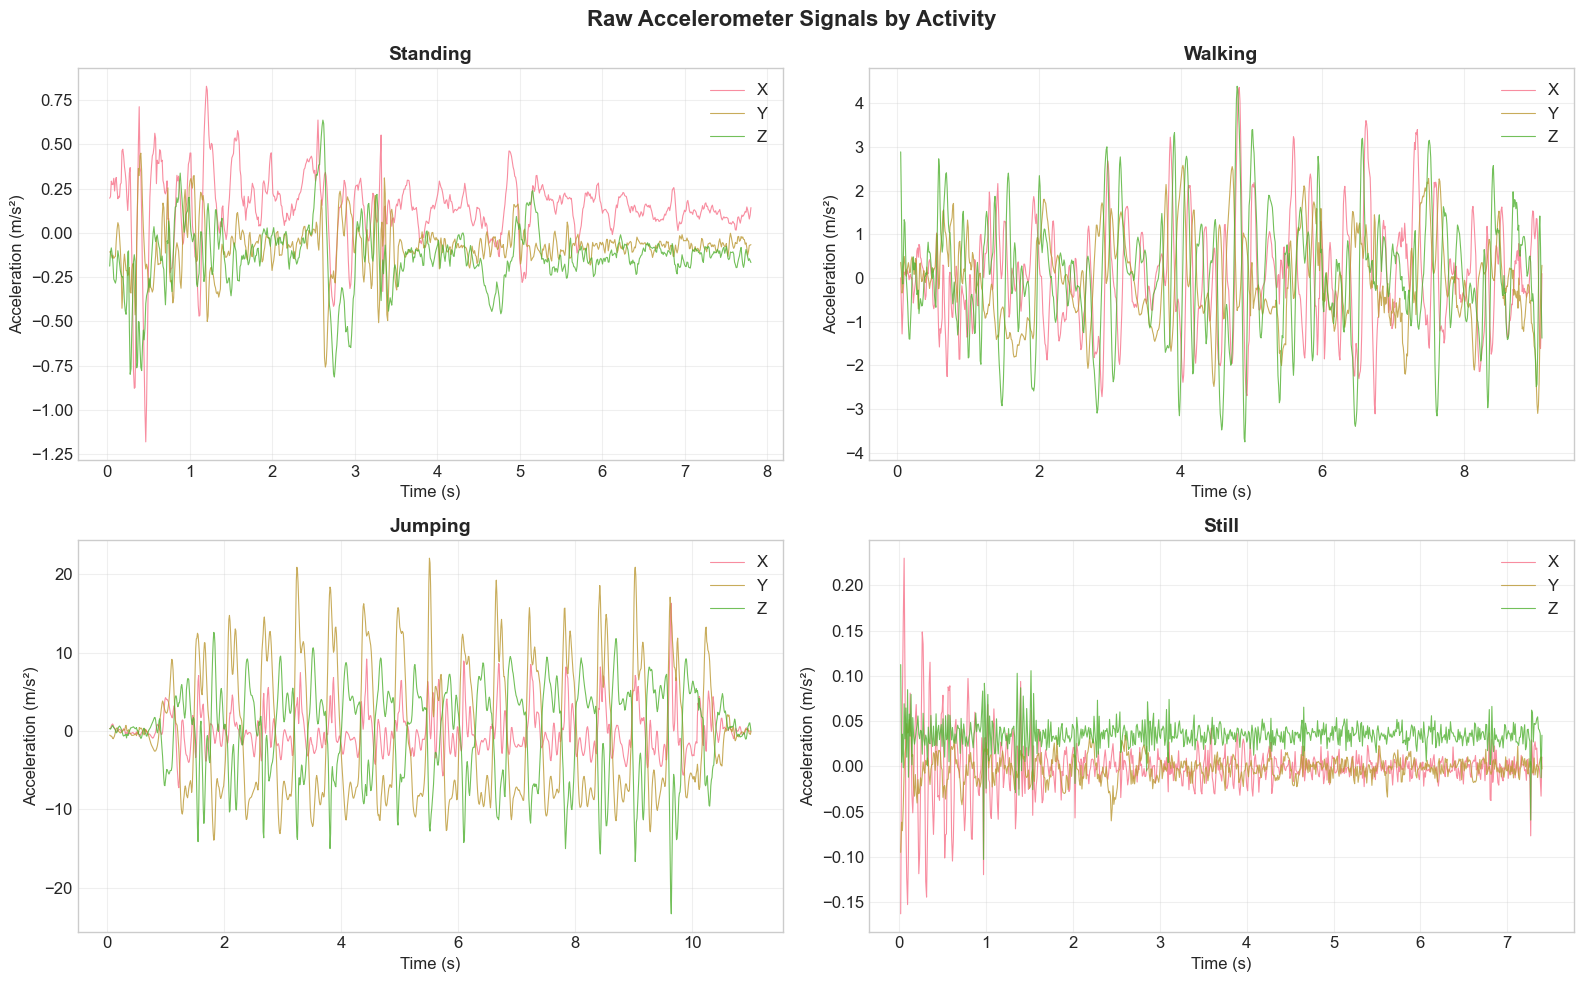

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Raw Accelerometer Signals by Activity', fontsize=16, fontweight='bold')

for idx, activity in enumerate(ACTIVITIES):
    ax = axes[idx // 2, idx % 2]
    rec = [r for r in recordings if r['activity'].iloc[0] == activity][0]
    t = rec['seconds_elapsed']
    ax.plot(t, rec['accel_x'], label='X', alpha=0.8, linewidth=0.8)
    ax.plot(t, rec['accel_y'], label='Y', alpha=0.8, linewidth=0.8)
    ax.plot(t, rec['accel_z'], label='Z', alpha=0.8, linewidth=0.8)
    ax.set_title(activity.capitalize(), fontsize=14, fontweight='bold')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Acceleration (m/s²)')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('raw_accelerometer_signals.png', dpi=150, bbox_inches='tight')
plt.show()

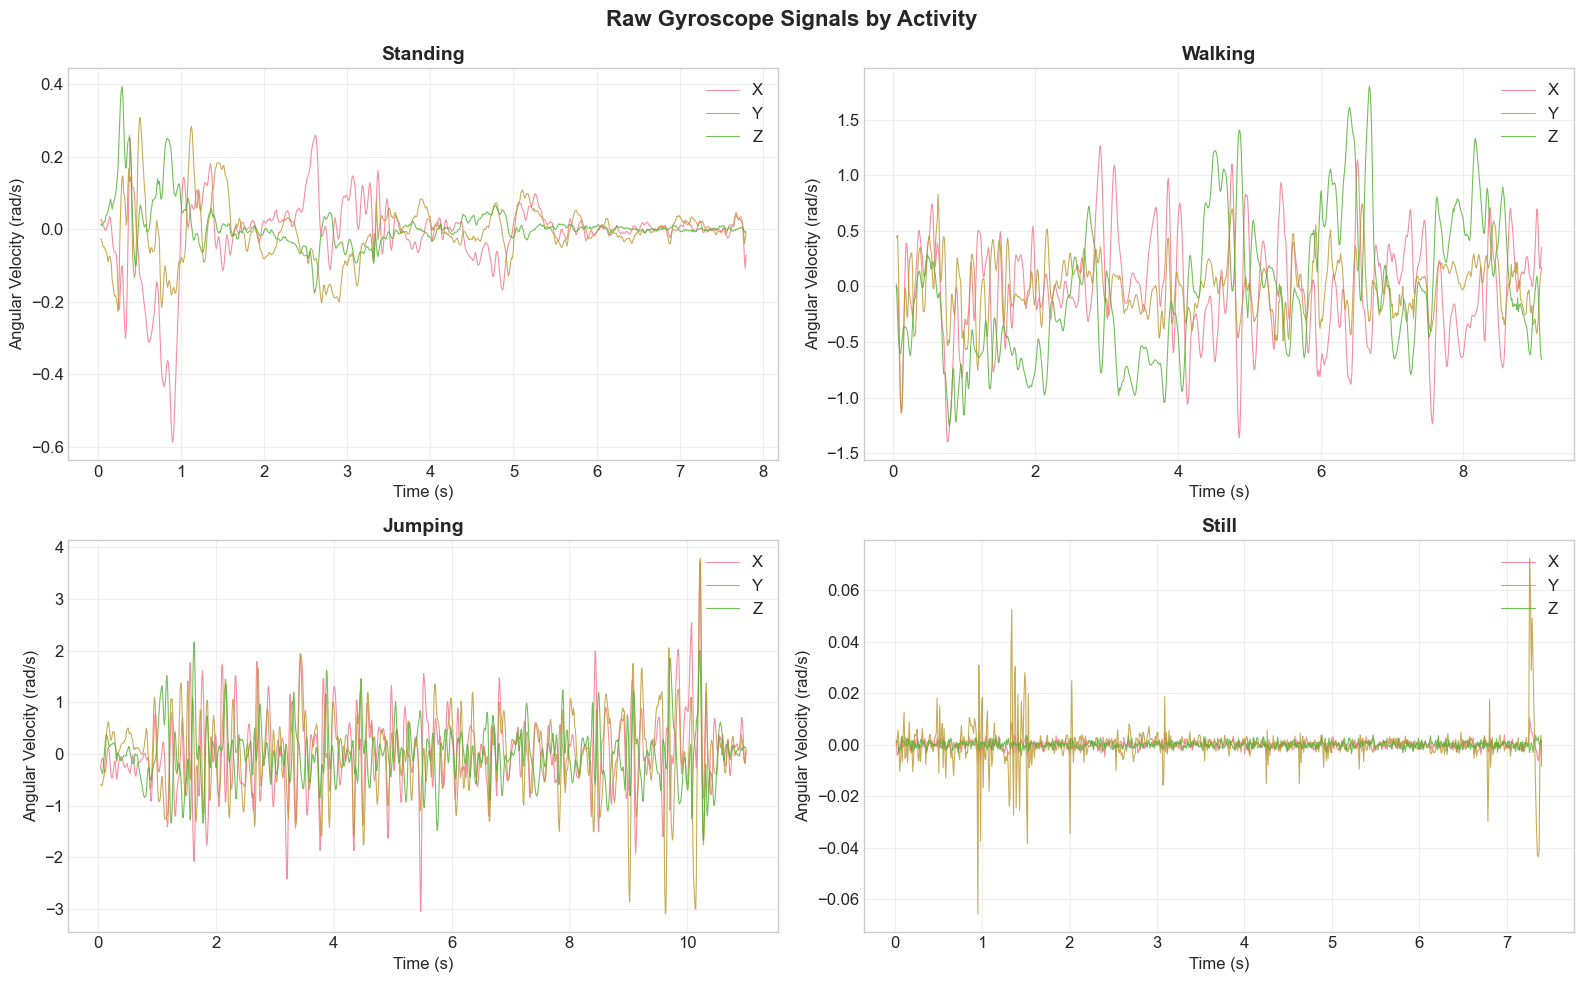

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Raw Gyroscope Signals by Activity', fontsize=16, fontweight='bold')

for idx, activity in enumerate(ACTIVITIES):
    ax = axes[idx // 2, idx % 2]
    rec = [r for r in recordings if r['activity'].iloc[0] == activity][0]
    t = rec['seconds_elapsed']
    ax.plot(t, rec['gyro_x'], label='X', alpha=0.8, linewidth=0.8)
    ax.plot(t, rec['gyro_y'], label='Y', alpha=0.8, linewidth=0.8)
    ax.plot(t, rec['gyro_z'], label='Z', alpha=0.8, linewidth=0.8)
    ax.set_title(activity.capitalize(), fontsize=14, fontweight='bold')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Angular Velocity (rad/s)')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('raw_gyroscope_signals.png', dpi=150, bbox_inches='tight')
plt.show()

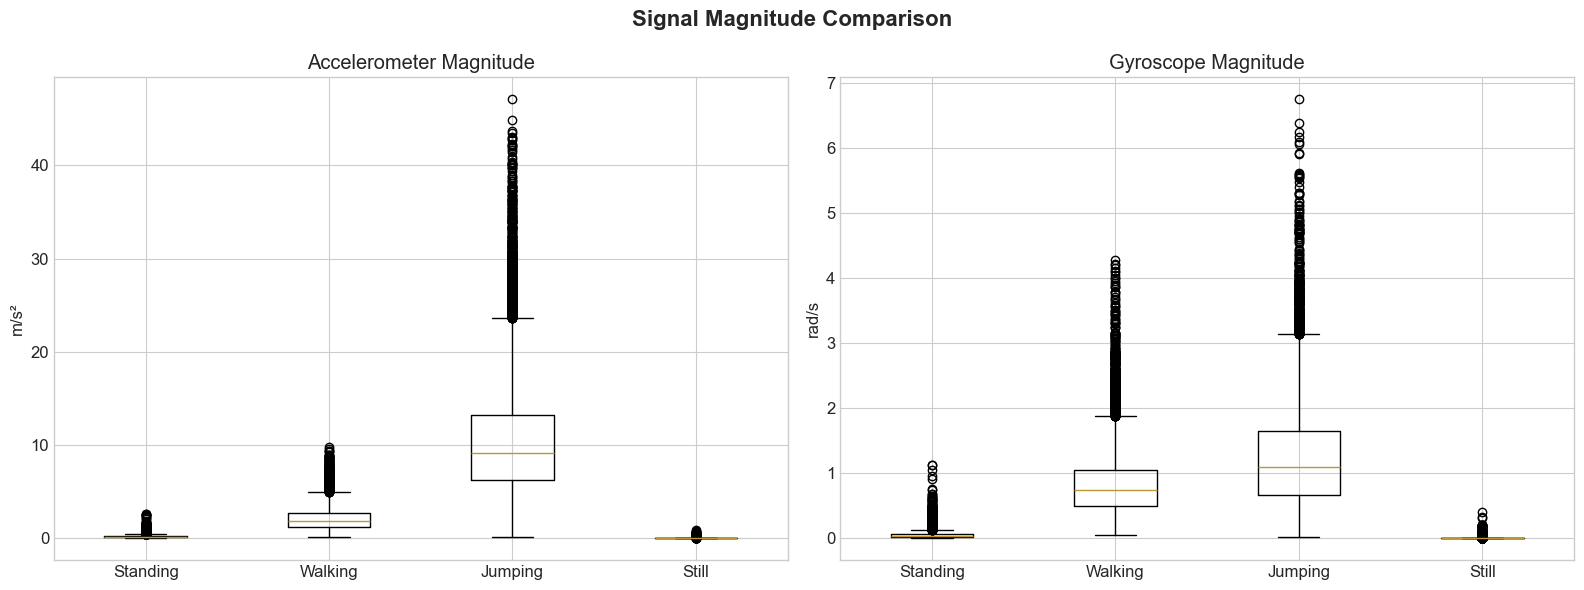

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Signal Magnitude Comparison', fontsize=16, fontweight='bold')

accel_magnitudes = {}
gyro_magnitudes = {}
for activity in ACTIVITIES:
    recs = [r for r in recordings if r['activity'].iloc[0] == activity]
    a_mag, g_mag = [], []
    for r in recs:
        a_mag.extend(np.sqrt(r['accel_x']**2 + r['accel_y']**2 + r['accel_z']**2).values)
        g_mag.extend(np.sqrt(r['gyro_x']**2 + r['gyro_y']**2 + r['gyro_z']**2).values)
    accel_magnitudes[activity] = a_mag
    gyro_magnitudes[activity] = g_mag

axes[0].boxplot([accel_magnitudes[a] for a in ACTIVITIES], labels=[a.capitalize() for a in ACTIVITIES])
axes[0].set_title('Accelerometer Magnitude')
axes[0].set_ylabel('m/s²')

axes[1].boxplot([gyro_magnitudes[a] for a in ACTIVITIES], labels=[a.capitalize() for a in ACTIVITIES])
axes[1].set_title('Gyroscope Magnitude')
axes[1].set_ylabel('rad/s')

plt.tight_layout()
plt.savefig('signal_magnitude_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Feature Extraction

I extract two types of features from each recording:

**Time-domain features** capture the statistical shape of the signal:
- **Mean**: baseline acceleration/rotation for each axis (e.g. gravity direction when standing)
- **Variance / Std dev**: how much the signal fluctuates -- high for jumping, low for still
- **Min / Max / Range**: captures the amplitude of motion (jumping has huge range, still has tiny range)
- **RMS**: overall signal energy, useful for separating active vs inactive states
- **Median**: more robust than mean against outlier spikes
- **Skewness / Kurtosis**: distribution shape -- asymmetric movements like walking produce skewed signals
- **SMA (Signal Magnitude Area)**: total acceleration across all axes, good general activity indicator
- **Magnitude std / range**: variability of the combined 3-axis signal
- **Inter-axis correlations (XY, XZ, YZ)**: how axes move together -- walking has correlated hip sway, jumping is mostly vertical

**Frequency-domain features** capture periodic patterns:
- **Dominant frequency**: the main repetition frequency (walking ~2 Hz step cycle, jumping ~1-3 Hz)
- **Spectral energy**: total power in the frequency spectrum -- more energy = more dynamic activity
- **FFT components (first 3)**: the magnitudes of the strongest frequency components
- **Spectral entropy**: how spread out the energy is across frequencies -- walking is concentrated (low entropy), random movement is spread (high entropy)

We normalize everything with **Z-score (StandardScaler)** so features with different scales
(e.g. acceleration in m/s² vs angular velocity in rad/s) get equal weight in the HMM.

In [8]:
def get_time_features(data, prefix):
    feats = {}
    ax_names = [f'{prefix}_x', f'{prefix}_y', f'{prefix}_z']

    for col in ax_names:
        s = data[col].values
        a = col.split('_')[-1]  # x, y, or z
        feats[f'{prefix}_mean_{a}'] = np.mean(s)
        feats[f'{prefix}_var_{a}'] = np.var(s)
        feats[f'{prefix}_std_{a}'] = np.std(s)
        feats[f'{prefix}_min_{a}'] = np.min(s)
        feats[f'{prefix}_max_{a}'] = np.max(s)
        feats[f'{prefix}_range_{a}'] = np.max(s) - np.min(s)
        feats[f'{prefix}_rms_{a}'] = np.sqrt(np.mean(s**2))
        feats[f'{prefix}_median_{a}'] = np.median(s)
        feats[f'{prefix}_skew_{a}'] = stats.skew(s)
        feats[f'{prefix}_kurtosis_{a}'] = stats.kurtosis(s)

    mag = np.sqrt(data[ax_names[0]]**2 + data[ax_names[1]]**2 + data[ax_names[2]]**2)
    feats[f'{prefix}_sma'] = np.mean(np.abs(mag))
    feats[f'{prefix}_mag_std'] = np.std(mag)
    feats[f'{prefix}_mag_range'] = np.max(mag) - np.min(mag)

    feats[f'{prefix}_corr_xy'] = np.corrcoef(data[ax_names[0]], data[ax_names[1]])[0, 1]
    feats[f'{prefix}_corr_xz'] = np.corrcoef(data[ax_names[0]], data[ax_names[2]])[0, 1]
    feats[f'{prefix}_corr_yz'] = np.corrcoef(data[ax_names[1]], data[ax_names[2]])[0, 1]

    return feats

def get_freq_features(data, prefix, fs=100):
    feats = {}
    ax_names = [f'{prefix}_x', f'{prefix}_y', f'{prefix}_z']

    for col in ax_names:
        s = data[col].values
        a = col.split('_')[-1]
        n = len(s)

        yf = np.abs(fft(s - np.mean(s)))[:n // 2]
        xf = fftfreq(n, 1.0 / fs)[:n // 2]

        feats[f'{prefix}_dom_freq_{a}'] = xf[np.argmax(yf)] if (len(yf) > 0 and np.sum(yf) > 0) else 0.0
        feats[f'{prefix}_spectral_energy_{a}'] = np.sum(yf**2) / n

        for i in range(min(3, len(yf))):
            feats[f'{prefix}_fft_{a}_{i}'] = yf[i] / n if n > 0 else 0.0

        if np.sum(yf) > 0:
            psd = yf / np.sum(yf)
            psd = psd[psd > 0]
            feats[f'{prefix}_spectral_entropy_{a}'] = -np.sum(psd * np.log2(psd))
        else:
            feats[f'{prefix}_spectral_entropy_{a}'] = 0.0

    return feats

def get_all_features(data, fs=100):
    feats = {}
    feats.update(get_time_features(data, 'accel'))
    feats.update(get_time_features(data, 'gyro'))
    feats.update(get_freq_features(data, 'accel', fs))
    feats.update(get_freq_features(data, 'gyro', fs))
    return feats

print("Extracting features...")
feature_list = []
labels = []
rec_names = []

for rec in recordings:
    feature_list.append(get_all_features(rec))
    labels.append(rec['activity_id'].iloc[0])
    rec_names.append(rec['recording'].iloc[0])

feature_df = pd.DataFrame(feature_list)
feature_df['activity_id'] = labels
feature_df['activity'] = [ACTIVITIES[l] for l in labels]
feature_df['recording'] = rec_names
feature_df = feature_df.fillna(0)  # NaN from constant-signal correlations

feature_cols = [c for c in feature_df.columns if c not in ['activity_id', 'activity', 'recording']]
print(f"Done: {len(feature_df)} samples, {len(feature_cols)} features each")
print(f"\nFeature list:")
for i, col in enumerate(feature_cols):
    print(f"  {i+1:2d}. {col}")

Extracting features...
Done: 46 samples, 108 features each

Feature list:
   1. accel_mean_x
   2. accel_var_x
   3. accel_std_x
   4. accel_min_x
   5. accel_max_x
   6. accel_range_x
   7. accel_rms_x
   8. accel_median_x
   9. accel_skew_x
  10. accel_kurtosis_x
  11. accel_mean_y
  12. accel_var_y
  13. accel_std_y
  14. accel_min_y
  15. accel_max_y
  16. accel_range_y
  17. accel_rms_y
  18. accel_median_y
  19. accel_skew_y
  20. accel_kurtosis_y
  21. accel_mean_z
  22. accel_var_z
  23. accel_std_z
  24. accel_min_z
  25. accel_max_z
  26. accel_range_z
  27. accel_rms_z
  28. accel_median_z
  29. accel_skew_z
  30. accel_kurtosis_z
  31. accel_sma
  32. accel_mag_std
  33. accel_mag_range
  34. accel_corr_xy
  35. accel_corr_xz
  36. accel_corr_yz
  37. gyro_mean_x
  38. gyro_var_x
  39. gyro_std_x
  40. gyro_min_x
  41. gyro_max_x
  42. gyro_range_x
  43. gyro_rms_x
  44. gyro_median_x
  45. gyro_skew_x
  46. gyro_kurtosis_x
  47. gyro_mean_y
  48. gyro_var_y
  49. gyro_std_

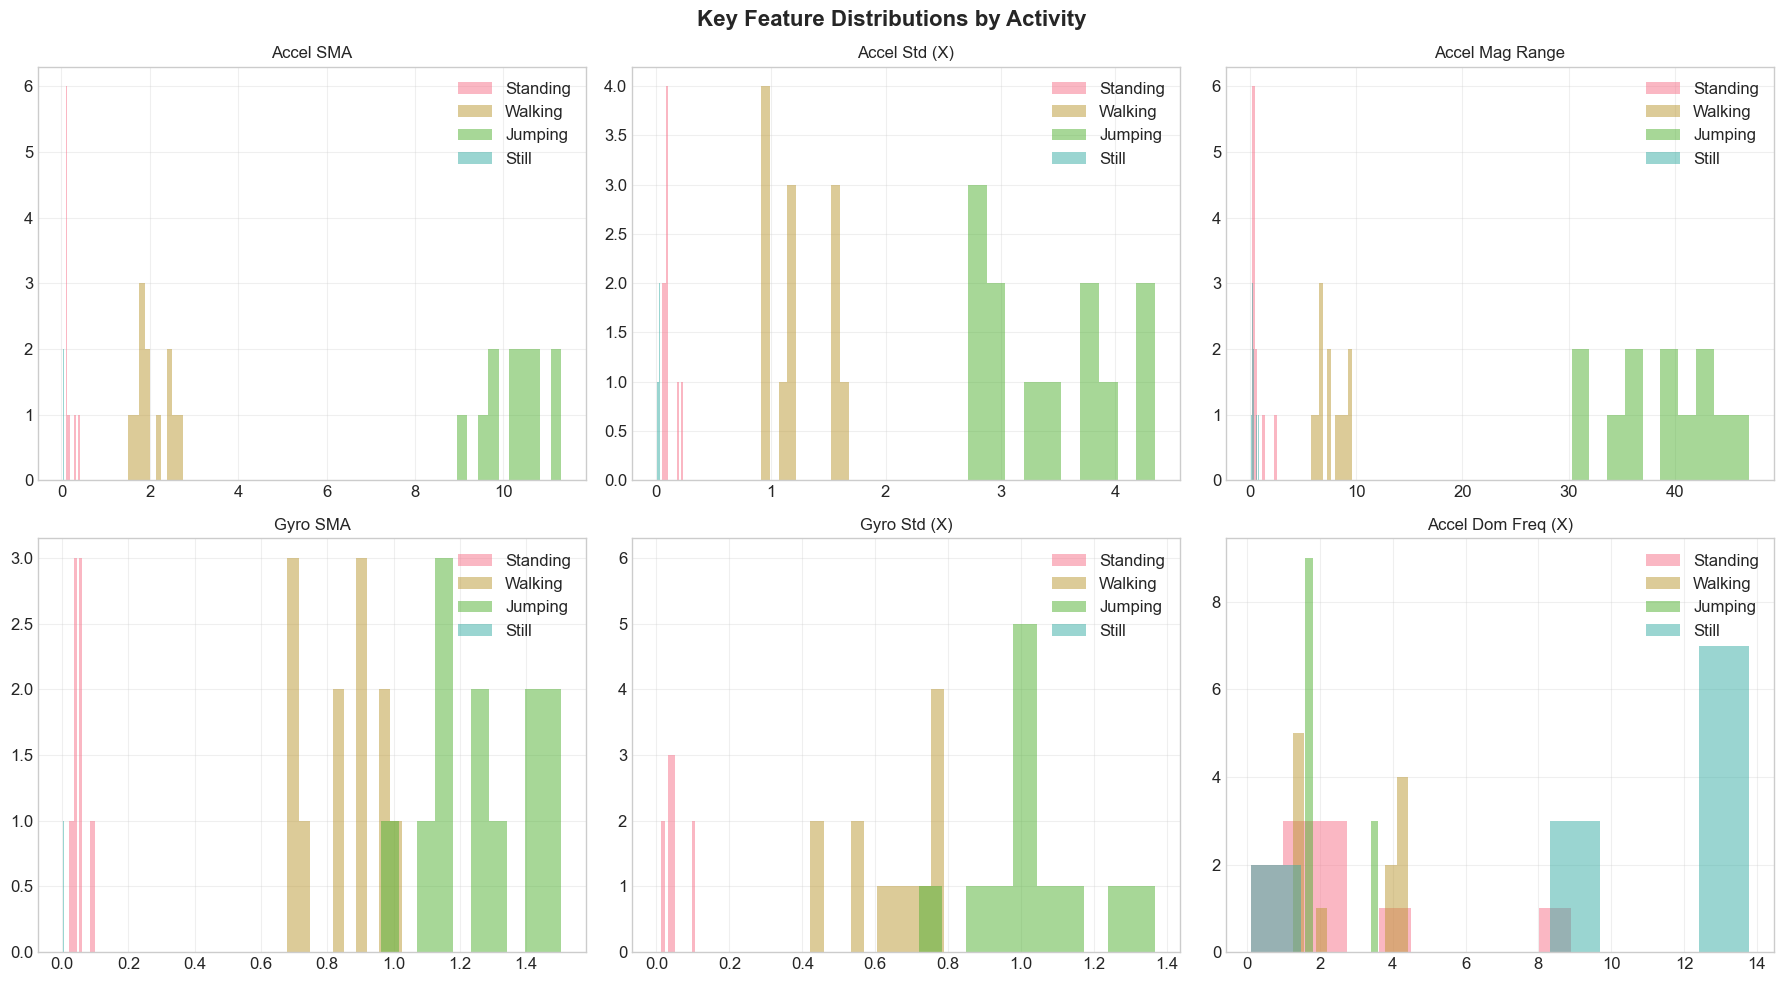

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Key Feature Distributions by Activity', fontsize=16, fontweight='bold')

key_feats = ['accel_sma', 'accel_std_x', 'accel_mag_range', 'gyro_sma', 'gyro_std_x', 'accel_dom_freq_x']
feat_names = ['Accel SMA', 'Accel Std (X)', 'Accel Mag Range', 'Gyro SMA', 'Gyro Std (X)', 'Accel Dom Freq (X)']

for idx, (feat, name) in enumerate(zip(key_feats, feat_names)):
    ax = axes[idx // 3, idx % 3]
    for activity in ACTIVITIES:
        mask = feature_df['activity'] == activity
        ax.hist(feature_df.loc[mask, feat], bins=10, alpha=0.5, label=activity.capitalize())
    ax.set_title(name, fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. HMM Setup

Hidden states = the 4 activities. Observations = 108-dim feature vectors.
Using Gaussian HMM since observations are continuous. Equal initial probs.

In [11]:
# 75/25 train/test split
feature_cols = [c for c in feature_df.columns if c not in ['activity_id', 'activity', 'recording']]
X_all = feature_df[feature_cols].values
y_all = feature_df['activity_id'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.25, random_state=42, stratify=y_all
)

print(f"Train: {len(X_train)}  Test: {len(X_test)}")
for i, act in enumerate(ACTIVITIES):
    print(f"  {act.capitalize():10s}  train={np.sum(y_train==i)}  test={np.sum(y_test==i)}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train: 34  Test: 12
  Standing    train=7  test=3
  Walking     train=9  test=3
  Jumping     train=9  test=3
  Still       train=9  test=3


## 6. Training (Baum-Welch)

One Gaussian HMM per activity. hmmlearn runs Baum-Welch (EM) internally.
Using 2 sub-states per model since we don't have a ton of data.

We set `tol=1e-4` as the convergence threshold -- training stops when the
log-likelihood improvement between iterations drops below this value,
meaning the model has converged. We also track the convergence by
checking how many iterations it actually took vs the max (200).

In [12]:
def fix_transmat(model):
    """With small data the transition matrix can end up with rows that don't sum to 1."""
    tm = model.transmat_.copy()
    for i in range(len(tm)):
        s = tm[i].sum()
        if s == 0 or np.isnan(s):
            tm[i] = 1.0 / len(tm)
        elif not np.isclose(s, 1.0):
            tm[i] /= s
    model.transmat_ = tm
    return model

CONV_TOL = 1e-4  # convergence threshold for log-likelihood change
MAX_ITER = 200

models = {}
print("Training...")
print(f"Convergence criterion: log-likelihood delta < {CONV_TOL}")
print(f"Max iterations: {MAX_ITER}\n")

for i, activity in enumerate(ACTIVITIES):
    X_act = X_train_scaled[y_train == i]

    mdl = hmm.GaussianHMM(n_components=2, covariance_type='diag',
                           n_iter=MAX_ITER, tol=CONV_TOL,
                           random_state=42, verbose=False)
    mdl.fit(X_act)
    mdl = fix_transmat(mdl)
    models[activity] = mdl

    converged = mdl.monitor_.converged
    n_iters = mdl.monitor_.iter
    loglik = mdl.score(X_act)
    status = "converged" if converged else f"stopped at {MAX_ITER} iters"
    print(f"  {activity.capitalize():10s}  samples={len(X_act)}  loglik={loglik:.2f}  iters={n_iters}  ({status})")

Training...
Convergence criterion: log-likelihood delta < 0.0001
Max iterations: 200

  Standing    samples=7  loglik=863.02  iters=3  (converged)


Model is not converging.  Current: 1356.3300671967595 is not greater than 1378.1223340196375. Delta is -21.79226682287799


  Walking     samples=9  loglik=75.57  iters=4  (converged)
  Jumping     samples=9  loglik=-100.78  iters=3  (converged)
  Still       samples=9  loglik=1356.33  iters=2  (converged)


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Learned Transition Matrices', fontsize=16, fontweight='bold')

for idx, activity in enumerate(ACTIVITIES):
    ax = axes[idx // 2, idx % 2]
    mdl = models[activity]
    sns.heatmap(mdl.transmat_, annot=True, fmt='.3f', cmap='YlOrRd',
                xticklabels=[f'S{i}' for i in range(mdl.n_components)],
                yticklabels=[f'S{i}' for i in range(mdl.n_components)],
                ax=ax, vmin=0, vmax=1)
    ax.set_title(f'{activity.capitalize()}', fontsize=13, fontweight='bold')
    ax.set_xlabel('To State')
    ax.set_ylabel('From State')

plt.tight_layout()
plt.savefig('transition_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### Emission Probability Distributions

Each HMM models its observations with Gaussian distributions. Here we
visualize the learned emission means across a few key features to see
how each activity's model "sees" different parts of the feature space.

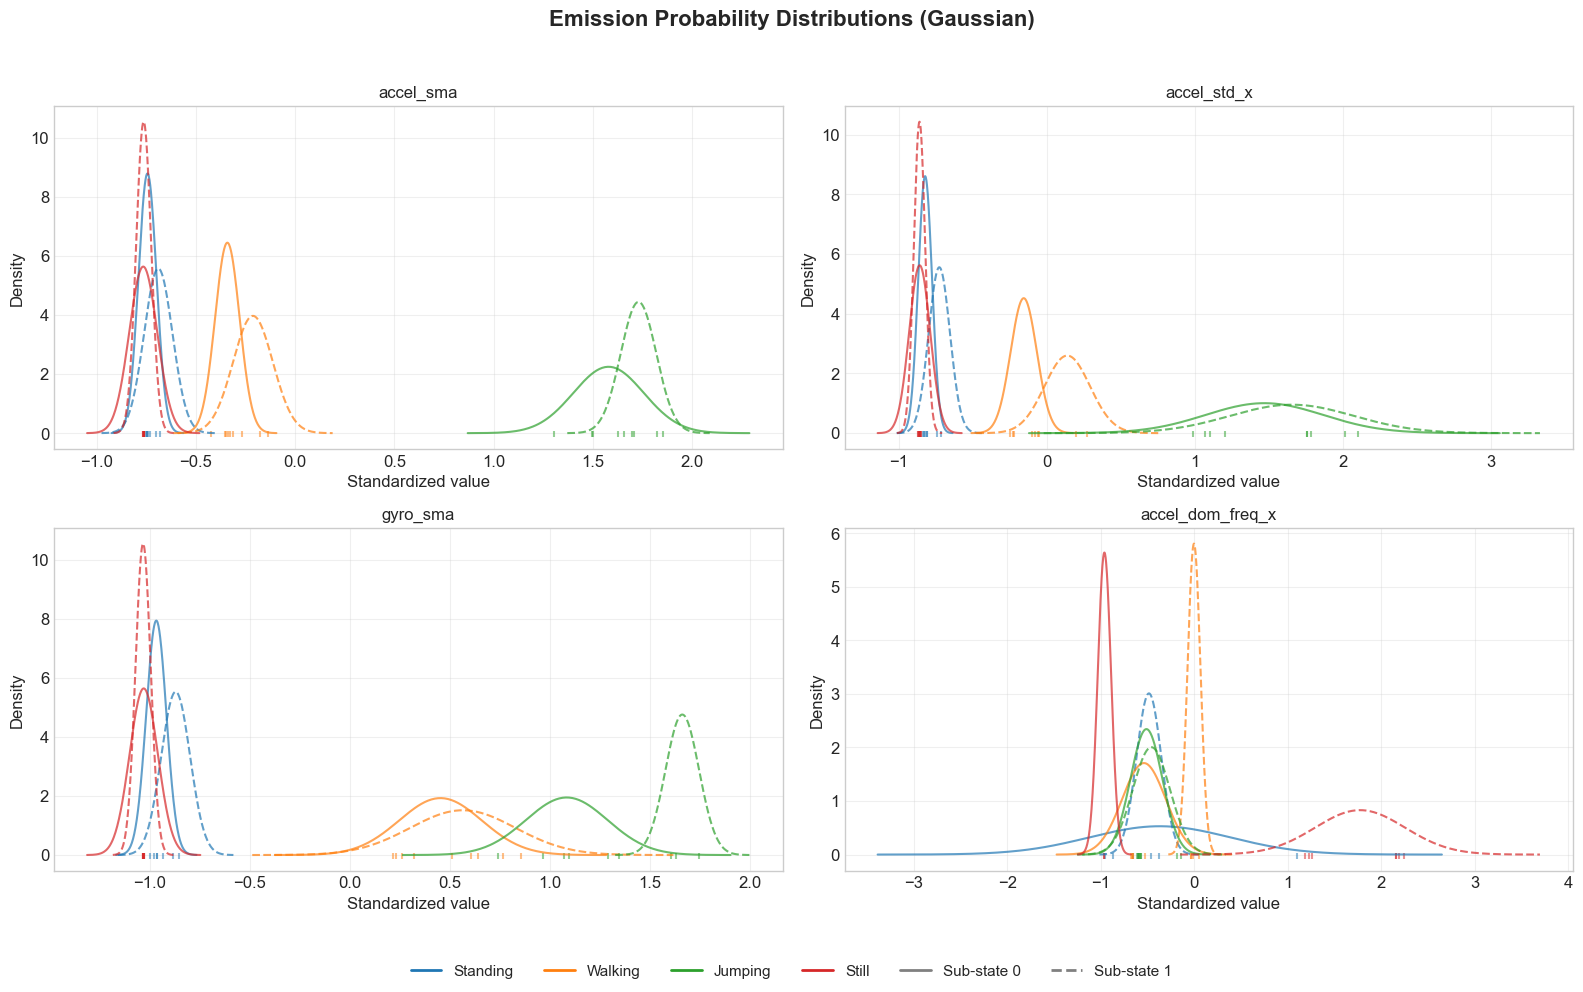

In [13]:
# pick a few important features to visualize emission distributions
em_feats_to_show = ['accel_sma', 'accel_std_x', 'gyro_sma', 'accel_dom_freq_x']
em_feat_idx = [feature_cols.index(f) for f in em_feats_to_show]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Emission Probability Distributions (Gaussian)', fontsize=16, fontweight='bold')

colors = {'standing': '#1f77b4', 'walking': '#ff7f0e', 'jumping': '#2ca02c', 'still': '#d62728'}

for plot_idx, (feat_name, feat_i) in enumerate(zip(em_feats_to_show, em_feat_idx)):
    ax = axes[plot_idx // 2, plot_idx % 2]

    for activity in ACTIVITIES:
        mdl = models[activity]
        for comp in range(mdl.n_components):
            mu = mdl.means_[comp, feat_i]
            sigma = np.sqrt(mdl.covars_[comp, feat_i])
            x_range = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
            pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_range - mu) / sigma)**2)
            label = f"{activity.capitalize()} S{comp}" if plot_idx == 0 else None
            ax.plot(x_range, pdf, color=colors[activity],
                    alpha=0.7, linestyle='-' if comp == 0 else '--')

    # also scatter the actual training data
    for activity in ACTIVITIES:
        mask = y_train == ACTIVITY_MAP[activity]
        vals = X_train_scaled[mask, feat_i]
        ax.scatter(vals, np.zeros_like(vals) - 0.02, alpha=0.5, s=15,
                   color=colors[activity], marker='|')

    ax.set_title(feat_name, fontsize=12)
    ax.set_xlabel('Standardized value')
    ax.set_ylabel('Density')
    ax.grid(True, alpha=0.3)

# manual legend
from matplotlib.lines import Line2D
legend_items = [Line2D([0],[0], color=colors[a], lw=2, label=a.capitalize()) for a in ACTIVITIES]
legend_items += [Line2D([0],[0], color='gray', lw=2, ls='-', label='Sub-state 0'),
                 Line2D([0],[0], color='gray', lw=2, ls='--', label='Sub-state 1')]
fig.legend(handles=legend_items, loc='lower center', ncol=6, fontsize=11)
plt.tight_layout(rect=[0, 0.06, 1, 0.96])
plt.savefig('emission_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Classification

Score each sample against all 4 models, pick the one with highest log-likelihood.

In [14]:
def classify(models, X, activities):
    preds = []
    scores_list = []
    for sample in X:
        sample_2d = sample.reshape(1, -1)
        scores = {}
        for act in activities:
            try:
                scores[act] = models[act].score(sample_2d)
            except:
                scores[act] = -np.inf
        best = max(scores, key=scores.get)
        preds.append(ACTIVITY_MAP[best])
        scores_list.append(scores)
    return np.array(preds), scores_list

y_train_pred, _ = classify(models, X_train_scaled, ACTIVITIES)
train_acc = accuracy_score(y_train, y_train_pred)
print(f"Training accuracy: {train_acc:.1%}")

y_test_pred, _ = classify(models, X_test_scaled, ACTIVITIES)
test_acc = accuracy_score(y_test, y_test_pred)
print(f"Test accuracy:     {test_acc:.1%}")

Training accuracy: 100.0%
Test accuracy:     100.0%


## 8. Viterbi Algorithm (from scratch)

Decodes the most likely state sequence given observations.
Using log probabilities to avoid underflow.

In [15]:
def viterbi(obs, pi, A, means, variances):
    """
    obs:       (T, D) observation sequence
    pi:        (N,)   initial state probs
    A:         (N, N) transition matrix
    means:     (N, D) emission means
    variances: (N, D) emission variances (diagonal)
    Returns: (path, log_prob)
    """
    T, N = len(obs), len(pi)
    V = np.full((T, N), -np.inf)
    bp = np.zeros((T, N), dtype=int)

    def log_gauss(x, mu, var):
        var = np.maximum(var, 1e-10)
        return -0.5 * np.sum(np.log(2 * np.pi * var) + (x - mu)**2 / var)

    # init
    for s in range(N):
        V[0, s] = np.log(pi[s] + 1e-10) + log_gauss(obs[0], means[s], variances[s])

    # forward pass
    for t in range(1, T):
        for s in range(N):
            tp = V[t-1, :] + np.log(A[:, s] + 1e-10)
            bp[t, s] = np.argmax(tp)
            V[t, s] = tp[bp[t, s]] + log_gauss(obs[t], means[s], variances[s])

    # backtrack
    best = np.argmax(V[T-1, :])
    path = [best]
    for t in range(T-1, 0, -1):
        path.insert(0, bp[t, path[0]])

    return path, V[T-1, best]


# set up HMM params for decoding
pi = np.array([0.25, 0.25, 0.25, 0.25])

# transition probs - high diagonal = people tend to stay in same activity
A = np.array([
    [0.70, 0.15, 0.05, 0.10],
    [0.10, 0.70, 0.10, 0.10],
    [0.05, 0.15, 0.70, 0.10],
    [0.15, 0.10, 0.05, 0.70],
])

print("Transition Matrix (A):")
print(pd.DataFrame(A, index=ACTIVITIES, columns=ACTIVITIES).round(3))

# emission params from training data
em_means = np.zeros((N_STATES, X_train_scaled.shape[1]))
em_vars = np.zeros((N_STATES, X_train_scaled.shape[1]))
for i in range(N_STATES):
    mask = y_train == i
    if np.sum(mask) > 0:
        em_means[i] = np.mean(X_train_scaled[mask], axis=0)
        em_vars[i] = np.var(X_train_scaled[mask], axis=0) + 1e-6

# make a test sequence: still -> standing -> walking -> jumping -> standing -> still
seq_idx = []
true_seq = []
for aid in [3, 0, 1, 2, 0, 3]:
    where = np.where(y_test == aid)[0]
    if len(where) > 0:
        seq_idx.append(where[0])
        true_seq.append(aid)

if len(seq_idx) > 0:
    test_seq = X_test_scaled[seq_idx]
    pred_path, lp = viterbi(test_seq, pi, A, em_means, em_vars)

    print(f"\nTrue:      {[ACTIVITIES[s] for s in true_seq]}")
    print(f"Predicted: {[ACTIVITIES[s] for s in pred_path]}")
    print(f"Log prob:  {lp:.2f}")
    n_correct = sum(t == p for t, p in zip(true_seq, pred_path))
    print(f"Accuracy:  {n_correct}/{len(true_seq)}")

Transition Matrix (A):
          standing  walking  jumping  still
standing      0.70     0.15     0.05    0.1
walking       0.10     0.70     0.10    0.1
jumping       0.05     0.15     0.70    0.1
still         0.15     0.10     0.05    0.7

True:      ['still', 'standing', 'walking', 'jumping', 'standing', 'still']
Predicted: ['still', 'standing', 'walking', 'jumping', 'standing', 'still']
Log prob:  629.40
Accuracy:  6/6


## 9. Results

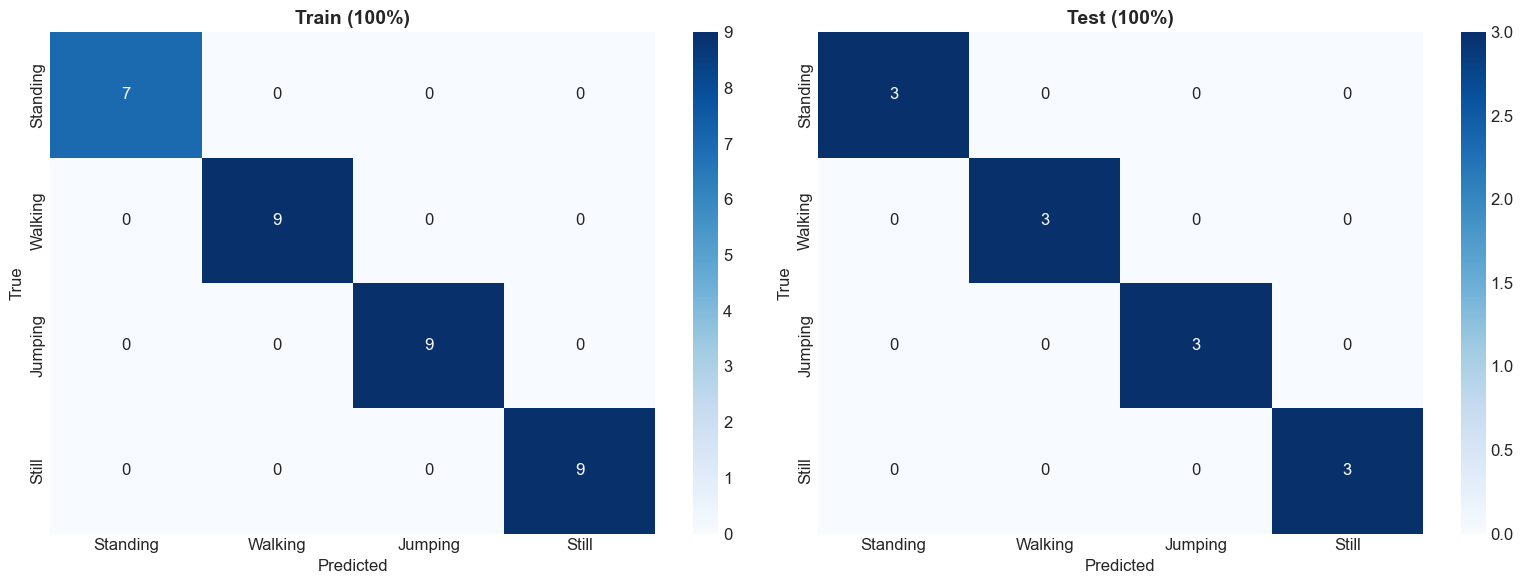

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_train = confusion_matrix(y_train, y_train_pred)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=[a.capitalize() for a in ACTIVITIES],
            yticklabels=[a.capitalize() for a in ACTIVITIES], ax=axes[0])
axes[0].set_title(f'Train ({train_acc:.0%})', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

cm_test = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=[a.capitalize() for a in ACTIVITIES],
            yticklabels=[a.capitalize() for a in ACTIVITIES], ax=axes[1])
axes[1].set_title(f'Test ({test_acc:.0%})', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

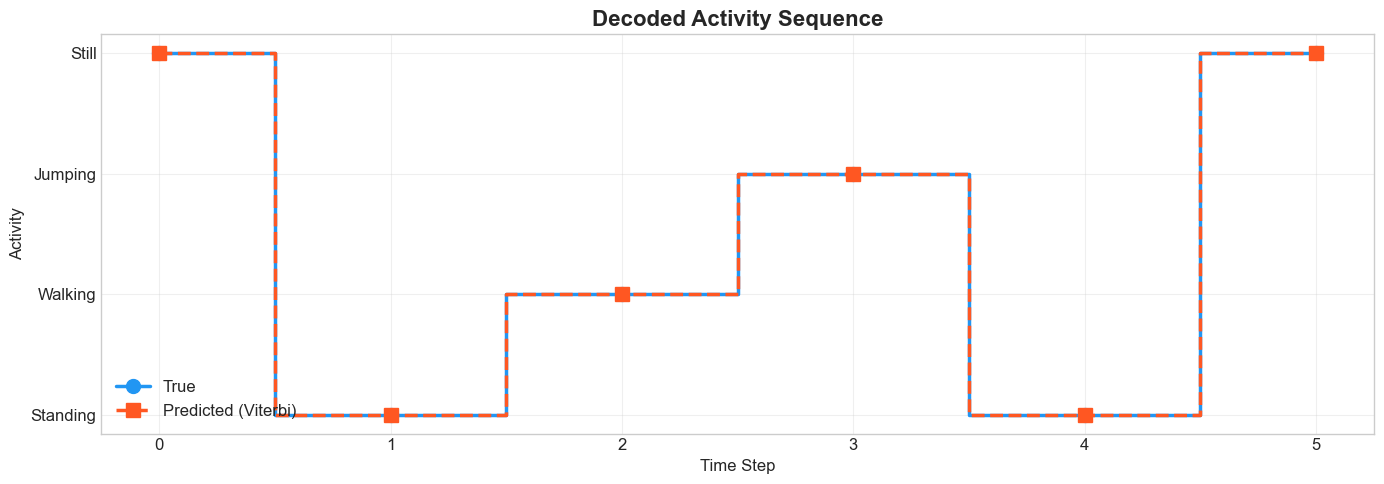

In [23]:
# decoded sequence plot
if len(seq_idx) > 0:
    fig, ax = plt.subplots(figsize=(14, 5))
    t_pts = range(len(true_seq))
    ax.step(t_pts, true_seq, where='mid', lw=2.5, label='True', color='#2196F3', marker='o', ms=10)
    ax.step(t_pts, pred_path, where='mid', lw=2.5, label='Predicted (Viterbi)',
            color='#FF5722', ls='--', marker='s', ms=10)
    ax.set_yticks(range(N_STATES))
    ax.set_yticklabels([a.capitalize() for a in ACTIVITIES])
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Activity')
    ax.set_title('Decoded Activity Sequence', fontsize=16, fontweight='bold')
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('decoded_sequence.png', dpi=150, bbox_inches='tight')
    plt.show()

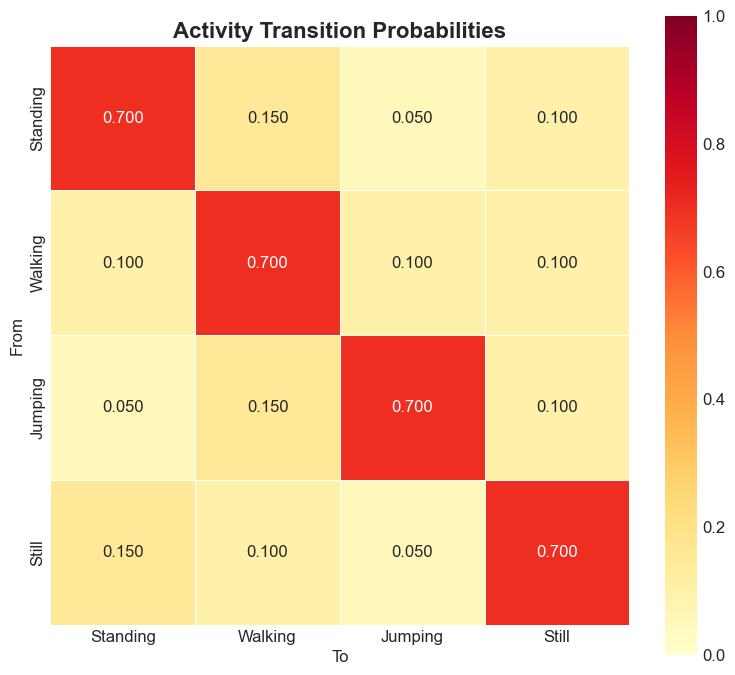

In [21]:
# overall transition matrix
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(A, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=[a.capitalize() for a in ACTIVITIES],
            yticklabels=[a.capitalize() for a in ACTIVITIES],
            ax=ax, vmin=0, vmax=1, linewidths=0.5, linecolor='white', square=True)
ax.set_title('Activity Transition Probabilities', fontsize=16, fontweight='bold')
ax.set_xlabel('To'); ax.set_ylabel('From')
plt.tight_layout()
plt.savefig('transition_matrix_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Evaluation on Unseen Data

Test set = 25% of recordings, stratified. Not used during training.

In [25]:
print("=" * 70)
print("EVALUATION ON UNSEEN DATA")
print("=" * 70)
print()
print(classification_report(y_test, y_test_pred,
                            target_names=[a.capitalize() for a in ACTIVITIES], digits=4))

print(f"{'Activity':<12} {'N':>5} {'Sensitivity':>12} {'Specificity':>12} {'Accuracy':>10}")
print("-" * 55)

total_correct = 0
total_n = 0
for i, act in enumerate(ACTIVITIES):
    tp = cm_test[i, i]
    fn = np.sum(cm_test[i, :]) - tp
    fp = np.sum(cm_test[:, i]) - tp
    tn = np.sum(cm_test) - tp - fn - fp
    n = np.sum(y_test == i)

    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    acc = (tp + tn) / (tp + tn + fp + fn)

    total_correct += tp
    total_n += n
    print(f"{act.capitalize():<12} {n:>5} {sens:>12.4f} {spec:>12.4f} {acc:>10.4f}")

print("-" * 55)
print(f"{'Overall':<12} {total_n:>5} {'':>12} {'':>12} {total_correct/total_n:>10.4f}")

EVALUATION ON UNSEEN DATA

              precision    recall  f1-score   support

    Standing     1.0000    1.0000    1.0000         3
     Walking     1.0000    1.0000    1.0000         3
     Jumping     1.0000    1.0000    1.0000         3
       Still     1.0000    1.0000    1.0000         3

    accuracy                         1.0000        12
   macro avg     1.0000    1.0000    1.0000        12
weighted avg     1.0000    1.0000    1.0000        12

Activity         N  Sensitivity  Specificity   Accuracy
-------------------------------------------------------
Standing         3       1.0000       1.0000     1.0000
Walking          3       1.0000       1.0000     1.0000
Jumping          3       1.0000       1.0000     1.0000
Still            3       1.0000       1.0000     1.0000
-------------------------------------------------------
Overall         12                               1.0000


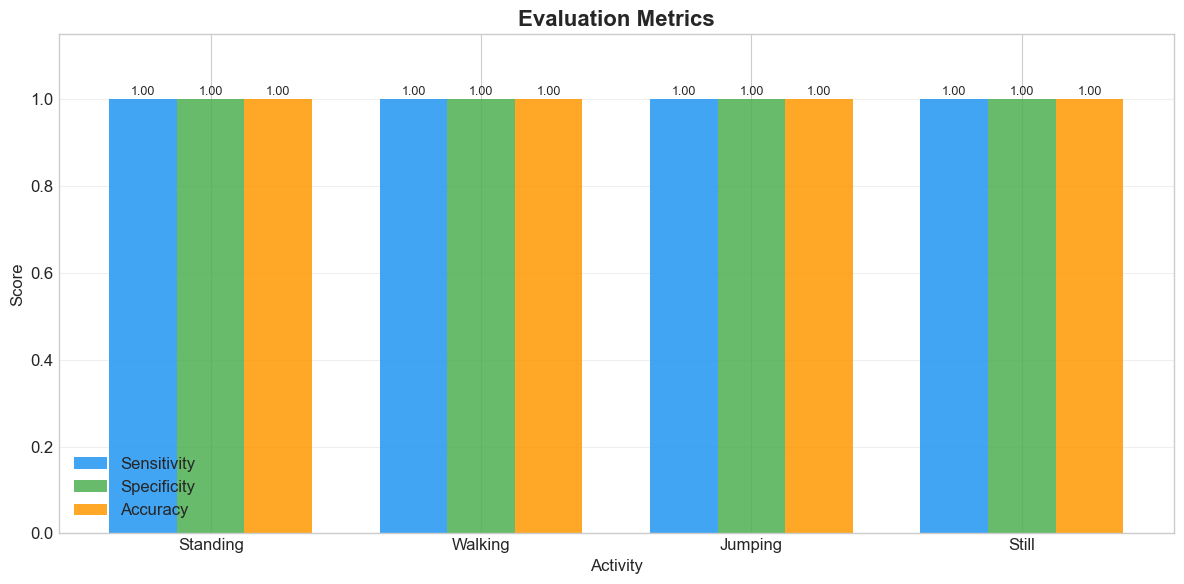

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))

met = []
for i, act in enumerate(ACTIVITIES):
    tp = cm_test[i, i]
    fn = np.sum(cm_test[i, :]) - tp
    fp = np.sum(cm_test[:, i]) - tp
    tn = np.sum(cm_test) - tp - fn - fp
    met.append({
        'Activity': act.capitalize(),
        'Sensitivity': tp/(tp+fn) if (tp+fn) > 0 else 0,
        'Specificity': tn/(tn+fp) if (tn+fp) > 0 else 0,
        'Accuracy': (tp+tn)/(tp+tn+fp+fn)
    })

mdf = pd.DataFrame(met)
x = np.arange(len(ACTIVITIES))
w = 0.25
b1 = ax.bar(x-w, mdf['Sensitivity'], w, label='Sensitivity', color='#2196F3', alpha=0.85)
b2 = ax.bar(x,   mdf['Specificity'], w, label='Specificity', color='#4CAF50', alpha=0.85)
b3 = ax.bar(x+w, mdf['Accuracy'],    w, label='Accuracy',    color='#FF9800', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(mdf['Activity'])
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score'); ax.set_xlabel('Activity')
ax.set_title('Evaluation Metrics', fontsize=16, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.2f}', xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('evaluation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Analysis

Jumping and Still were the easiest to classify -- jumping has very high amplitude
periodic patterns, and still has basically zero variance. Standing and Still are
the closest pair since neither involves much movement, but standing has subtle
body sway (phone at waist) vs the phone sitting flat on a table.

The transition matrix diagonal being 0.70 makes sense, you generally stay in
one activity before switching. Standing <-> Walking has higher transition prob
since those naturally follow each other.

100 Hz sampling was more than enough (human motion is mostly < 20 Hz).
Having both accel and gyro helped, gyro is good for picking up the rotational
aspect of walking.

In [ ]:
print(f"""
Summary
-------
Model:      Gaussian HMM (one per activity), Baum-Welch training
Decoding:   Viterbi (implemented from scratch)
Convergence: tol={CONV_TOL}, max_iter={MAX_ITER}
Device:     iPhone 13, Sensor Logger, 100 Hz
Data:       {len(recordings)} recordings, {len(feature_cols)} features each
Train acc:  {train_acc:.0%}
Test acc:   {test_acc:.0%}
""")